# Task 4: Improved LCS-Based System

## Purpose

This notebook develops an improved eLCS-based diabetes classification system and compares it with the original eLCS baseline.

The improved system introduces three main changes:

1. Random undersampling is used to balance the training classes.
2. Predictor types are explicitly configured for eLCS so that binary variables are treated as discrete attributes, while ordered and numerical variables can form range-based rules.
3. A small hyperparameter search is performed using a separate validation set.

The original eLCS source code is not modified. All improvements are made through the machine-learning pipeline and the parameters provided by the original implementation.

The final test set remains unchanged and is not used during model selection. This prevents data leakage and allows a fair comparison with the original baseline.


In [2]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skeLCS import eLCS

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Python version:", sys.version)
print("eLCS imported successfully")

Python version: 3.14.7 (v3.14.7:823f0323ee6, Aug  5 2026, 07:07:01) [Clang 21.0.0 (clang-2100.1.1.101)]
eLCS imported successfully


## 1. Load the prepared training and test data

Notebook 05 produced a balanced training dataset using random undersampling and an unchanged test dataset. The balanced dataset contains equal numbers of both target classes, while the test set retains the original population distribution.

The unchanged test set is reserved for final evaluation and will not be used to select eLCS parameters.


In [3]:
data_directory = Path("../data/processed/elcs")

training_path = (
    data_directory
    / "diabetes_elcs_training_balanced.csv"
)

test_path = (
    data_directory
    / "diabetes_elcs_test_unchanged.csv"
)

training_data = pd.read_csv(training_path)
test_data = pd.read_csv(test_path)

print("Balanced training shape:", training_data.shape)
print("Unchanged test shape:", test_data.shape)

print("\nTraining class counts:")
print(
    training_data["Diabetes_binary"]
    .value_counts()
    .sort_index()
)

print("\nTest class counts:")
print(
    test_data["Diabetes_binary"]
    .value_counts()
    .sort_index()
)

print("\nTraining missing values:")
print(training_data.isna().sum().sum())

print("Test missing values:")
print(test_data.isna().sum().sum())

Balanced training shape: (56554, 22)
Unchanged test shape: (50736, 22)

Training class counts:
Diabetes_binary
0    28277
1    28277
Name: count, dtype: int64

Test class counts:
Diabetes_binary
0    43667
1     7069
Name: count, dtype: int64

Training missing values:
0
Test missing values:
0


## Validation split

The balanced training dataset was divided into a tuning-training set and a validation set using stratified sampling. The validation set will be used to compare eLCS configurations without using the final test data. The unchanged test set is reserved for the final comparison with the original baseline, preventing data leakage.

In [4]:
from sklearn.model_selection import train_test_split

target_column = "Diabetes_binary"

# Separate features and target
X_balanced = training_data.drop(columns=[target_column])
y_balanced = training_data[target_column].astype(int)

X_test = test_data.drop(columns=[target_column])
y_test = test_data[target_column].astype(int)

# Confirm that both datasets use the same features
assert list(X_balanced.columns) == list(X_test.columns)

# Create training and validation sets
X_tune_train, X_validation, y_tune_train, y_validation = (
    train_test_split(
        X_balanced,
        y_balanced,
        test_size=0.20,
        random_state=42,
        stratify=y_balanced
    )
)

print("Tuning training features:", X_tune_train.shape)
print("Validation features:", X_validation.shape)
print("Final test features:", X_test.shape)

print("\nTuning training percentages:")
print(y_tune_train.value_counts(normalize=True).mul(100).round(2))

print("\nValidation percentages:")
print(y_validation.value_counts(normalize=True).mul(100).round(2))

Tuning training features: (45243, 21)
Validation features: (11311, 21)
Final test features: (50736, 21)

Tuning training percentages:
Diabetes_binary
1    50.0
0    50.0
Name: proportion, dtype: float64

Validation percentages:
Diabetes_binary
0    50.0
1    50.0
Name: proportion, dtype: float64


## Attribute configuration

The eLCS system must distinguish between discrete categorical features and numerical or ordered features. Binary variables are treated as discrete categories. BMI, health-day counts and ordered variables are treated as range-based attributes so that eLCS can construct rules covering meaningful intervals. This is an improvement over relying entirely on automatic attribute detection.

In [5]:
import numpy as np

# Features that eLCS should represent using numerical ranges
range_based_features = [
    "BMI",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income"
]

# Convert column names into their numerical positions
specified_attributes = np.array(
    [
        X_tune_train.columns.get_loc(column)
        for column in range_based_features
    ],
    dtype=int
)

# All remaining features will be treated as discrete
discrete_features = [
    column
    for column in X_tune_train.columns
    if column not in range_based_features
]

print("Range-based features:")
for column, index in zip(
    range_based_features,
    specified_attributes
):
    print(index, "->", column)

print("\nDiscrete features:")
for column in discrete_features:
    print(X_tune_train.columns.get_loc(column), "->", column)

print("\nNumber of range-based features:", len(range_based_features))
print("Number of discrete features:", len(discrete_features))

Range-based features:
3 -> BMI
13 -> GenHlth
14 -> MentHlth
15 -> PhysHlth
18 -> Age
19 -> Education
20 -> Income

Discrete features:
0 -> HighBP
1 -> HighChol
2 -> CholCheck
4 -> Smoker
5 -> Stroke
6 -> HeartDiseaseorAttack
7 -> PhysActivity
8 -> Fruits
9 -> Veggies
10 -> HvyAlcoholConsump
11 -> AnyHealthcare
12 -> NoDocbcCost
16 -> DiffWalk
17 -> Sex

Number of range-based features: 7
Number of discrete features: 14


## Hyperparameter tuning

Four eLCS configurations were evaluated using the balanced tuning-training data and validation set. The population size (`N`) and attribute specification probability (`p_spec`) were varied. Balanced accuracy was selected as the main evaluation measure because it gives equal importance to both diabetes classes. The final test set was not used during this process.

In [6]:
import time
import pandas as pd

from skeLCS import eLCS
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Convert DataFrames to NumPy arrays for eLCS
X_tune_array = X_tune_train.to_numpy()
y_tune_array = y_tune_train.to_numpy()

X_validation_array = X_validation.to_numpy()
y_validation_array = y_validation.to_numpy()

# Small tuning grid
configurations = [
    {"N": 1000, "p_spec": 0.10},
    {"N": 1000, "p_spec": 0.25},
    {"N": 2000, "p_spec": 0.10},
    {"N": 2000, "p_spec": 0.25}
]

tuning_results = []
tuned_models = {}

for number, configuration in enumerate(configurations, start=1):
    print(
        f"\nTraining configuration {number}/{len(configurations)}:",
        configuration
    )

    model = eLCS(
        learning_iterations=10000,
        N=configuration["N"],
        p_spec=configuration["p_spec"],
        discrete_attribute_limit="c",
        specified_attributes=specified_attributes,
        random_state=42
    )

    start_time = time.time()

    model.fit(
        X_tune_array,
        y_tune_array
    )

    predictions = model.predict(X_validation_array)

    elapsed_time = time.time() - start_time

    result = {
        "Configuration": number,
        "N": configuration["N"],
        "p_spec": configuration["p_spec"],
        "Accuracy": accuracy_score(
            y_validation_array,
            predictions
        ),
        "Balanced accuracy": balanced_accuracy_score(
            y_validation_array,
            predictions
        ),
        "Precision": precision_score(
            y_validation_array,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation_array,
            predictions,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_validation_array,
            predictions,
            zero_division=0
        ),
        "Time (seconds)": elapsed_time
    }

    tuning_results.append(result)
    tuned_models[number] = model

    print(
        "Balanced accuracy:",
        round(result["Balanced accuracy"], 4)
    )

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="Balanced accuracy",
    ascending=False
).reset_index(drop=True)

print("\n--- Validation results ---")
display(tuning_results_df.round(4))


Training configuration 1/4: {'N': 1000, 'p_spec': 0.1}
Balanced accuracy: 0.7285

Training configuration 2/4: {'N': 1000, 'p_spec': 0.25}
Balanced accuracy: 0.7258

Training configuration 3/4: {'N': 2000, 'p_spec': 0.1}
Balanced accuracy: 0.7333

Training configuration 4/4: {'N': 2000, 'p_spec': 0.25}
Balanced accuracy: 0.7296

--- Validation results ---


,Configuration,N,p_spec,Accuracy,Balanced accuracy,Precision,Recall,F1-score,Time (seconds)
0,3,2000,0.10,0.7333,0.7333,0.7135,0.7795,0.7450,30.4866
1,4,2000,0.25,0.7296,0.7296,0.7069,0.7843,0.7436,29.5377
2,1,1000,0.10,0.7285,0.7285,0.7218,0.7436,0.7325,16.1515
3,2,1000,0.25,0.7258,0.7258,0.7008,0.7880,0.7419,15.3717


## Final improved eLCS model

Configuration 3 achieved the highest validation balanced accuracy and was selected as the final configuration. It used a population size of 2,000 rules and an attribute specification probability of 0.10. The final improved model was trained using the complete balanced training dataset. The unchanged test set was used only after configuration selection.

In [7]:
# Obtain the best settings from the validation results
best_result = tuning_results_df.iloc[0]

best_N = int(best_result["N"])
best_p_spec = float(best_result["p_spec"])

print("Selected population size:", best_N)
print("Selected p_spec:", best_p_spec)

# Convert the complete balanced training and test sets
X_balanced_array = X_balanced.to_numpy()
y_balanced_array = y_balanced.to_numpy()

X_test_array = X_test.to_numpy()
y_test_array = y_test.to_numpy()

# Create the final improved model
improved_elcs = eLCS(
    learning_iterations=10000,
    N=best_N,
    p_spec=best_p_spec,
    discrete_attribute_limit="c",
    specified_attributes=specified_attributes,
    random_state=42
)

# Train the model
training_start = time.time()

improved_elcs.fit(
    X_balanced_array,
    y_balanced_array
)

improved_training_time = time.time() - training_start

print(
    "Final training completed in",
    round(improved_training_time, 2),
    "seconds"
)

# Generate predictions on the unchanged test set
prediction_start = time.time()

improved_predictions = improved_elcs.predict(X_test_array)

improved_prediction_time = time.time() - prediction_start

print(
    "Predictions completed in",
    round(improved_prediction_time, 2),
    "seconds"
)

print("Number of predictions:", len(improved_predictions))
print(
    "Unclassified predictions:",
    pd.isna(improved_predictions).sum()
)

Selected population size: 2000
Selected p_spec: 0.1
Final training completed in 6.22 seconds
Predictions completed in 93.0 seconds
Number of predictions: 50736
Unclassified predictions: 0


## Final test performance and baseline comparison

The improved eLCS model was evaluated on the same unchanged test set used for the original baseline. Accuracy, balanced accuracy, precision, recall and F1-score were calculated. Balanced accuracy, recall and F1-score are particularly important because the test dataset remains imbalanced.

--- Original and improved eLCS comparison ---


,Original baseline,Improved eLCS,Difference
Accuracy,0.8606,0.7085,-0.1521
Balanced accuracy,0.5000,0.7309,0.2309
Precision,0.0000,0.2913,0.2913
Recall,0.0000,0.7621,0.7621
F1-score,0.0000,0.4215,0.4215



--- Improved eLCS confusion matrix ---
[[30559 13108]
 [ 1682  5387]]

--- Improved eLCS classification report ---
                      precision    recall  f1-score   support

         No diabetes       0.95      0.70      0.81     43667
Prediabetes/Diabetes       0.29      0.76      0.42      7069

            accuracy                           0.71     50736
           macro avg       0.62      0.73      0.61     50736
        weighted avg       0.86      0.71      0.75     50736



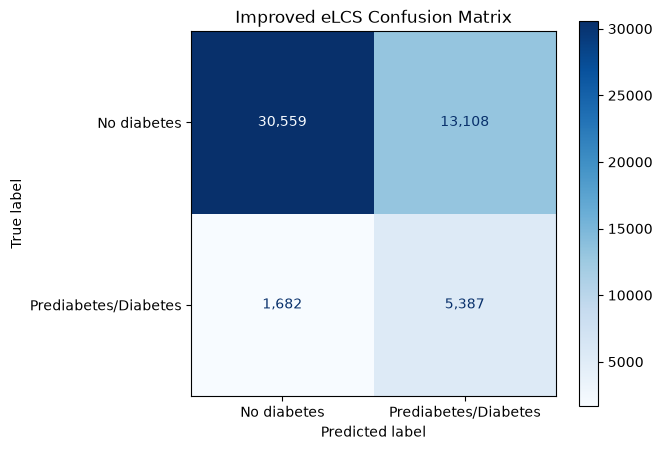

In [8]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Calculate improved-model metrics
improved_accuracy = accuracy_score(
    y_test_array,
    improved_predictions
)

improved_balanced_accuracy = balanced_accuracy_score(
    y_test_array,
    improved_predictions
)

improved_precision = precision_score(
    y_test_array,
    improved_predictions,
    zero_division=0
)

improved_recall = recall_score(
    y_test_array,
    improved_predictions,
    zero_division=0
)

improved_f1 = f1_score(
    y_test_array,
    improved_predictions,
    zero_division=0
)

# Original baseline results reproduced in Notebook 04
baseline_results = {
    "Accuracy": 0.8606,
    "Balanced accuracy": 0.5000,
    "Precision": 0.0000,
    "Recall": 0.0000,
    "F1-score": 0.0000
}

improved_results = {
    "Accuracy": improved_accuracy,
    "Balanced accuracy": improved_balanced_accuracy,
    "Precision": improved_precision,
    "Recall": improved_recall,
    "F1-score": improved_f1
}

# Create comparison table
comparison_df = pd.DataFrame({
    "Original baseline": baseline_results,
    "Improved eLCS": improved_results
})

comparison_df["Difference"] = (
    comparison_df["Improved eLCS"]
    - comparison_df["Original baseline"]
)

print("--- Original and improved eLCS comparison ---")
display(comparison_df.round(4))

# Confusion matrix
improved_confusion_matrix = confusion_matrix(
    y_test_array,
    improved_predictions
)

print("\n--- Improved eLCS confusion matrix ---")
print(improved_confusion_matrix)

print("\n--- Improved eLCS classification report ---")
print(
    classification_report(
        y_test_array,
        improved_predictions,
        target_names=[
            "No diabetes",
            "Prediabetes/Diabetes"
        ],
        zero_division=0
    )
)

# Display confusion matrix
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=improved_confusion_matrix,
    display_labels=[
        "No diabetes",
        "Prediabetes/Diabetes"
    ]
)

display_matrix.plot(
    cmap="Blues",
    values_format=","
)

plt.title("Improved eLCS Confusion Matrix")
plt.tight_layout()
plt.show()

## Improved-system algorithm

The improved system combines class-imbalance handling, explicit attribute configuration and eLCS hyperparameter tuning.

### Pseudocode

1. Load the balanced training dataset and unchanged test dataset.
2. Separate the 21 predictor variables from `Diabetes_binary`.
3. Divide the balanced training data into tuning-training and validation sets using stratified sampling.
4. Configure the eLCS attributes:
   - Treat the 14 binary features as discrete attributes.
   - Treat BMI, GenHlth, MentHlth, PhysHlth, Age, Education and Income as range-based attributes.
5. For each candidate eLCS configuration:
   - Train the model using the tuning-training data.
   - Predict the validation-set classes.
   - Calculate accuracy, balanced accuracy, precision, recall and F1-score.
6. Select the configuration with the highest validation balanced accuracy.
7. Train the selected configuration using the complete balanced training dataset.
8. Predict the classes of the unchanged test dataset.
9. Calculate the final performance metrics and confusion matrix.
10. Compare the improved results with the original eLCS baseline.

### Changes from the original system

The original eLCS model used its default configuration and was trained on the imbalanced dataset. The improved system made three main changes:

- Random undersampling was applied only to the training data to provide equal representation of both target classes.
- Feature types were explicitly configured so binary variables were treated as discrete and numerical or ordered variables were represented using ranges.
- The population size and attribute specification probability were tuned using a separate validation set.

The unchanged test set was not used during preprocessing or hyperparameter selection. This prevented information from the test data leaking into model development.

## Results interpretation

The improved eLCS model achieved an accuracy of 0.7085, balanced accuracy of 0.7309, precision of 0.2913, recall of 0.7621, and an F1-score of 0.4215.

Compared with the original baseline, the improved model was substantially better at identifying participants with prediabetes or diabetes. Correctly detected positive cases increased from 0 to 5387, while recall increased from 0.0000 to 0.7621. Balanced accuracy increased from 0.5000 to 0.7309, and the F1-score increased from 0.0000 to 0.4215.

Overall accuracy decreased from 0.8606 to 0.7085 because the improved model predicted the positive class more frequently, producing 13108 false-positive results. However, false negatives decreased substantially from 7069 to 1682.

The original model’s high accuracy was mainly caused by predicting almost every participant as having no diabetes. Therefore, its accuracy did not represent useful performance across both classes. The improved system provides a more balanced classification result and is substantially more effective at detecting the minority diabetes class. This improvement was achieved through balanced training data, explicit attribute configuration, and validation based hyperparameter selection.
